In [14]:
# .csv 中每一行有784个像素点（28 * 28，需要手动reshape），表示图片的颜色，构成数字图像

import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter 



In [15]:
# 可视化数字图片

def show_digit(idx):
    df = pd.read_csv('../data/手写数字识别.csv')
    print(df.shape)
    if idx < 0 or idx > len(df) - 1:
        print('index out of range')
        return
    
    x = df.iloc[:, 1:]
    y = df.iloc[:, 0]
    print(f'该图片对应的数字是：{y.iloc[idx]}')
    
    print(x.iloc[idx].shape)
    x = x.iloc[idx].values.reshape(28, 28)
    plt.imshow(x, cmap='gray')
    plt.axis('off')
    plt.show()



(42000, 785)
该图片对应的数字是：3
(784,)


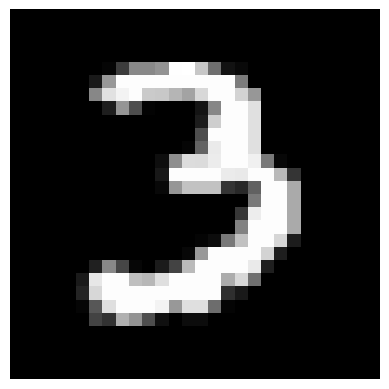

In [16]:
show_digit(9)

In [17]:
# 模型训练，评估，保存

def train_model():
    df = pd.read_csv('../data/手写数字识别.csv')
    x = df.iloc[:, 1:]
    y = df.iloc[:, 0]
    print(x.shape, y.shape)
    
    x = x / 255
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=13, stratify=y)
    
    estimator = KNeighborsClassifier(n_neighbors=3)
    estimator.fit(x_train, y_train)

    acc = accuracy_score(y_test, estimator.predict(x_test))
    print(f'acc: {acc}')

    joblib.dump(estimator, './knn_mnist.pkl')
    print('model saved!')

train_model()

(42000, 784) (42000,)
acc: 0.9642857142857143
model saved!


(28, 28)


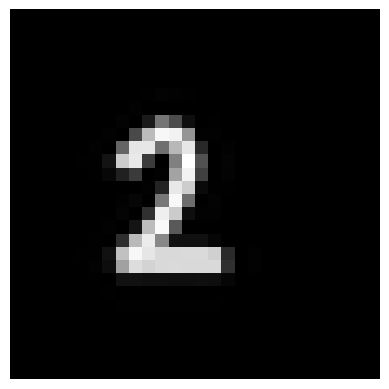

y_pred: [2]


/home/yj/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [18]:
# 读取模型，读取图片（28 * 28 -> 784），模型预测

def use_model():
    x = plt.imread('../data/demo.png')   # 读取的时候已经归一化了
    estimator = joblib.load('./knn_mnist.pkl')  
    print(x.shape)
    plt.imshow(x, cmap='gray')
    plt.axis('off')
    plt.show()
    # print(x)
    x = x.reshape(1, -1)

    y_pred = estimator.predict(x)
    print(f'y_pred: {y_pred}')
    
use_model()
